# EU-Park - Customer / Season-Pass EDA

**Consulting project for the theme park "EU-Park" (board: CEO + CTO).**

This notebook explores the **season-pass customer data** (`EU-Park-Customers.csv`) for goal **(c)**:

> *Predict which customers buy a season pass ("Gold" / "Silver") and understand what drives the decision.*

The snapshot reflects each customer's situation on **1 January** - the day they decided whether to buy a pass. This notebook covers the **exploratory phase**: data-quality checks, cleaning, and first insights that set up the classification model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)

In [2]:
customers = pd.read_csv("EU-Park-Customers.csv")
print("Shape:", customers.shape, "\n")
print(customers.dtypes, "\n")
customers.head()

Shape: (10000, 7) 

Age                             int64
Telephone_Number                  str
Family_Members_with_Passes      int64
Previously_Owned_Passes         int64
Club_Member                      bool
Distance_from_Park_km         float64
Pass_Type                         str
dtype: object 



,Age,Telephone_Number,Family_Members_with_Passes,Previously_Owned_Passes,Club_Member,Distance_from_Park_km,Pass_Type
0,56,+1-55701876,1,4,True,44.898168,Gold
1,69,+1-64152311,1,3,True,4.073727,Gold
2,46,+1-77547334,0,1,False,9.838632,NaN
3,32,+1-00176841,0,0,False,42.988060,NaN
4,60,+1-67664153,0,3,True,26.281220,Gold


## 1. First look & data quality

In [3]:
# Summary statistics for numeric + categorical columns
display(customers.describe(include="all").T)

print("Missing values per column:")
print(customers.isna().sum())
print("\nFull duplicate rows :", int(customers.duplicated().sum()))
print("Duplicate phone nums:", int(customers.Telephone_Number.duplicated().sum()))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,10000.0,NaN,NaN,NaN,43.5394,14.911636,18.0,31.0,43.0,56.0,69.0
Telephone_Number,10000,9999,+1-42660526,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family_Members_with_Passes,10000.0,NaN,NaN,NaN,0.7525,0.891809,0.0,0.0,1.0,1.0,3.0
Previously_Owned_Passes,10000.0,NaN,NaN,NaN,2.017,1.414606,0.0,1.0,2.0,3.0,4.0
Club_Member,10000,2,False,7981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_from_Park_km,10000.0,NaN,NaN,NaN,29.936617,29.455316,0.000826,8.600811,20.788702,41.993392,246.639786
Pass_Type,5628,2,Silver,2833,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values per column:
Age                              0
Telephone_Number                 0
Family_Members_with_Passes       0
Previously_Owned_Passes          0
Club_Member                      0
Distance_from_Park_km            0
Pass_Type                     4372
dtype: int64

Full duplicate rows : 0
Duplicate phone nums: 1


### The target column `Pass_Type`

`Pass_Type` is missing for 4,372 rows. These are **not missing data** - they are customers who simply **did not buy a pass**. We recode the NaNs to `"None"`.

`Telephone_Number` is an ID-like field (essentially unique: 9,999 distinct values out of 10,000) and carries no predictive signal, so it is dropped.

In [4]:
print("Pass_Type raw value counts (NaN included):")
print(customers.Pass_Type.value_counts(dropna=False))

Pass_Type raw value counts (NaN included):
Pass_Type
NaN       4372
Silver    2833
Gold      2795
Name: count, dtype: int64


In [5]:
cust = customers.copy()
cust["Pass_Type"] = cust["Pass_Type"].fillna("None")
cust = cust.drop(columns=["Telephone_Number"])

# Binary target as well: did the customer buy ANY pass?
cust["AnyPass"] = (cust["Pass_Type"] != "None").astype(int)

print(cust.Pass_Type.value_counts(), "\n")
print("Class shares:")
print((cust.Pass_Type.value_counts(normalize=True) * 100).round(1).astype(str) + " %")
print("\nAny-pass rate:", f"{cust.AnyPass.mean():.1%}")
print("Remaining missing values:", int(cust.drop(columns='AnyPass').isna().sum().sum()))

Pass_Type
None      4372
Silver    2833
Gold      2795
Name: count, dtype: int64 

Class shares:
Pass_Type
None      43.7 %
Silver    28.3 %
Gold      28.0 %
Name: proportion, dtype: str

Any-pass rate: 56.3%
Remaining missing values: 0


### Snapshot & target overview

A quick, presentation-ready view of the cleaned dataset (`cust`) and the season-pass target,
split across the three classes: **No Pass**, **Silver**, **Gold**.

**Data snapshot** — 10,000 customers × 7 columns &nbsp;|&nbsp; missing values: 0 &nbsp;|&nbsp; duplicate rows: 0

,Age,Family_Members_with_Passes,Previously_Owned_Passes,Club_Member,Distance_from_Park_km,Pass_Type,AnyPass
0,56,1,4,True,44.898168,Gold,1
1,69,1,3,True,4.073727,Gold,1
2,46,0,1,False,9.838632,None,0
3,32,0,0,False,42.988060,None,0
4,60,0,3,True,26.281220,Gold,1


**Season-pass target distribution**

,Customers,Share
Pass type,,
No Pass,"4,372",43.7 %
Silver,"2,833",28.3 %
Gold,"2,795",28.0 %


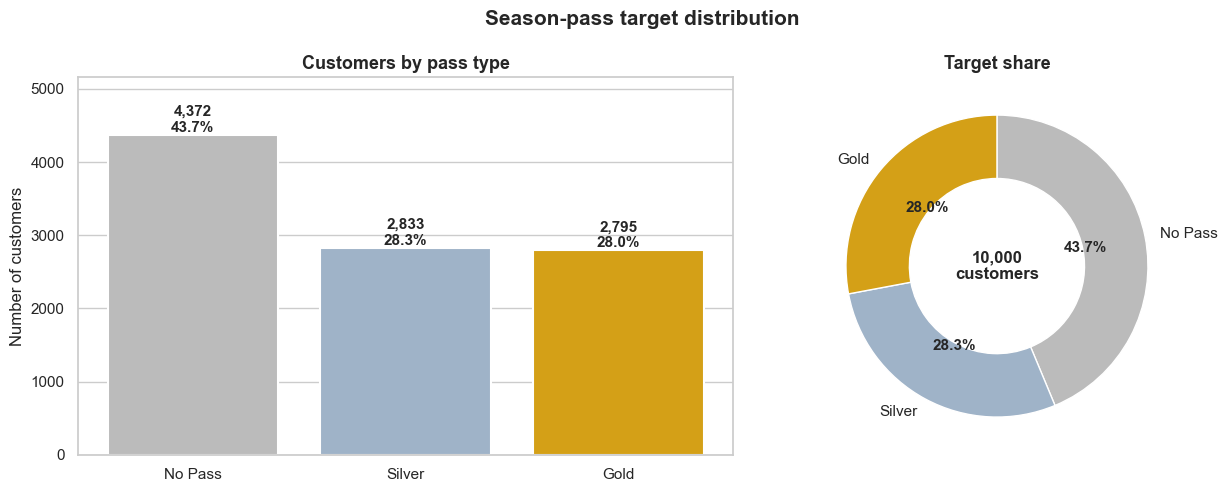

In [6]:
from IPython.display import display, Markdown

# ---- Display labels & consistent colours for the three classes ----
LABELS = {"None": "No Pass", "Silver": "Silver", "Gold": "Gold"}
order_raw  = ["None", "Silver", "Gold"]
order_disp = [LABELS[c] for c in order_raw]
class_colors = {"No Pass": "#bbbbbb", "Silver": "#9fb3c8", "Gold": "#d4a017"}

# ============================================================
# 1) DATA SNAPSHOT
# ============================================================
n_rows, n_cols = cust.shape
display(Markdown(
    f"**Data snapshot** — {n_rows:,} customers × {n_cols} columns "
    f"&nbsp;|&nbsp; missing values: {int(cust.isna().sum().sum())} "
    f"&nbsp;|&nbsp; duplicate rows: {int(cust.duplicated().sum())}"
))
display(cust.head())

# ============================================================
# 2) TARGET DISTRIBUTION TABLE (No Pass / Silver / Gold)
# ============================================================
counts = cust["Pass_Type"].value_counts().reindex(order_raw)
dist = pd.DataFrame({
    "Customers":  counts.values,
    "Share":      (counts / counts.sum() * 100).round(1).values,
})
dist.index = order_disp
dist.index.name = "Pass type"
dist_display = dist.assign(Share=dist["Share"].astype(str) + " %")
display(Markdown("**Season-pass target distribution**"))
display(
    dist_display.style
        .format({"Customers": "{:,}"})
        .set_caption(f"Any-pass rate: {cust['AnyPass'].mean():.1%}")
        .bar(subset=["Customers"], color="#cfe3f3")
)

# ============================================================
# 3) TARGET DISTRIBUTION CHARTS  (bar + donut)
# ============================================================
fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(13, 5),
                                      gridspec_kw={"width_ratios": [1.3, 1]})
bar_colors = [class_colors[c] for c in order_disp]

# --- Bar chart with count + share labels ---
bars = ax_bar.bar(order_disp, dist["Customers"], color=bar_colors,
                  edgecolor="white", linewidth=1.5)
for bar, pct in zip(bars, dist["Share"]):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{int(bar.get_height()):,}\n{pct:.1f}%",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax_bar.set_title("Customers by pass type", fontsize=13, fontweight="bold")
ax_bar.set_ylabel("Number of customers")
ax_bar.set_ylim(0, dist["Customers"].max() * 1.18)
ax_bar.grid(axis="x", visible=False)

# --- Donut chart ---
wedges, _, autotexts = ax_pie.pie(
    dist["Customers"], labels=order_disp, colors=bar_colors,
    autopct=lambda p: f"{p:.1f}%", startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white"),
    textprops=dict(fontsize=11))
for t in autotexts:
    t.set_fontweight("bold")
ax_pie.text(0, 0, f"{n_rows:,}\ncustomers", ha="center", va="center",
            fontsize=12, fontweight="bold")
ax_pie.set_title("Target share", fontsize=13, fontweight="bold")

plt.suptitle("Season-pass target distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Target share & customer age groups

The bar and donut above tell the same story, so we keep the **target-share donut** and pair
it with the **age profile** of the customer base, bucketed into 10-year groups.

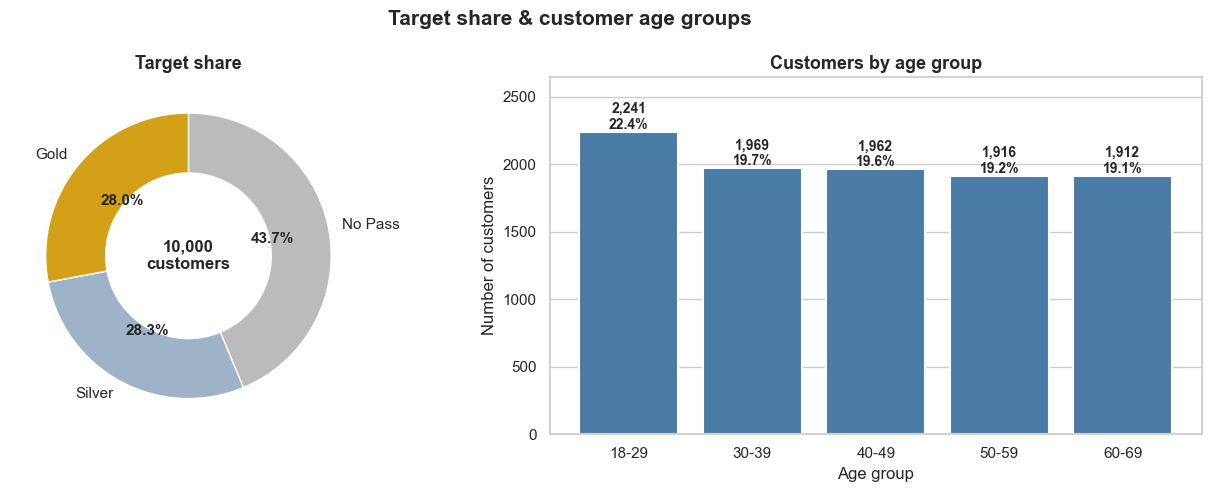

In [7]:
# Display labels/colours (re-defined so the cell runs standalone after prep)
order_raw  = ["None", "Silver", "Gold"]
order_disp = ["No Pass", "Silver", "Gold"]
bar_colors = ["#bbbbbb", "#9fb3c8", "#d4a017"]
n_rows = len(cust)

fig, (ax_pie, ax_age) = plt.subplots(1, 2, figsize=(13, 5),
                                     gridspec_kw={"width_ratios": [1, 1.3]})

# ---- LEFT: target-share donut (No Pass / Silver / Gold) ----
pie_counts = cust["Pass_Type"].value_counts().reindex(order_raw)
wedges, _, autotexts = ax_pie.pie(
    pie_counts.values, labels=order_disp, colors=bar_colors,
    autopct=lambda p: f"{p:.1f}%", startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white"),
    textprops=dict(fontsize=11))
for t in autotexts:
    t.set_fontweight("bold")
ax_pie.text(0, 0, f"{n_rows:,}\ncustomers", ha="center", va="center",
            fontsize=12, fontweight="bold")
ax_pie.set_title("Target share", fontsize=13, fontweight="bold")

# ---- RIGHT: customers by age group (10-year bins) ----
age_edges  = [18, 30, 40, 50, 60, 70]
age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69"]
age_grp = pd.cut(cust["Age"], bins=age_edges, labels=age_labels, right=False)
age_counts = age_grp.value_counts().reindex(age_labels)
age_share  = age_counts / age_counts.sum() * 100

bars = ax_age.bar(age_labels, age_counts.values, color="#4a7ba6",
                  edgecolor="white", linewidth=1.5)
for bar, pct in zip(bars, age_share.values):
    ax_age.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{int(bar.get_height()):,}\n{pct:.1f}%",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
ax_age.set_title("Customers by age group", fontsize=13, fontweight="bold")
ax_age.set_xlabel("Age group")
ax_age.set_ylabel("Number of customers")
ax_age.set_ylim(0, age_counts.max() * 1.18)
ax_age.grid(axis="x", visible=False)

plt.suptitle("Target share & customer age groups", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Key features vs pass type

How three of the strongest drivers differ across **No Pass / Silver / Gold**:
previous ownership, family members with passes, and distance from the park.

C:\Users\appen\AppData\Local\Temp\ipykernel_27432\954540270.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="PassLabel", y="Distance_from_Park_km",


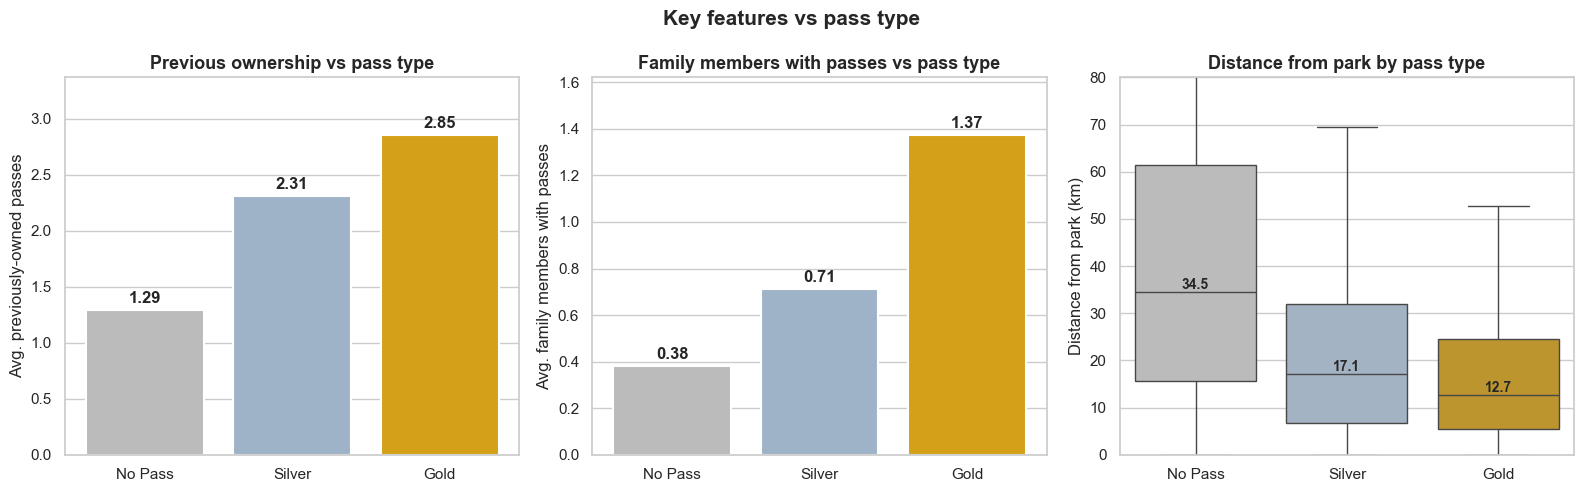

,Avg_Previously_Owned,Avg_Family_with_Passes,Median_Distance_km
PassLabel,,,
No Pass,1.29,0.38,34.47
Silver,2.31,0.71,17.13
Gold,2.85,1.37,12.72


In [8]:
# Reuse the display labels/colours from the snapshot cell (re-defined here so the
# cell also runs standalone after the prep step).
order_raw   = ["None", "Silver", "Gold"]
order_disp  = ["No Pass", "Silver", "Gold"]
bar_colors  = ["#bbbbbb", "#9fb3c8", "#d4a017"]

plot_df = cust.assign(PassLabel=cust["Pass_Type"].map(dict(zip(order_raw, order_disp))))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---- 1) Previous ownership vs pass type (avg passes previously owned) ----
m1 = plot_df.groupby("PassLabel")["Previously_Owned_Passes"].mean().reindex(order_disp)
b1 = axes[0].bar(order_disp, m1.values, color=bar_colors, edgecolor="white", linewidth=1.5)
axes[0].bar_label(b1, fmt="%.2f", padding=3, fontweight="bold")
axes[0].set_title("Previous ownership vs pass type", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Avg. previously-owned passes")
axes[0].set_ylim(0, m1.max() * 1.18); axes[0].grid(axis="x", visible=False)

# ---- 2) Family members with passes vs pass type (avg) ----
m2 = plot_df.groupby("PassLabel")["Family_Members_with_Passes"].mean().reindex(order_disp)
b2 = axes[1].bar(order_disp, m2.values, color=bar_colors, edgecolor="white", linewidth=1.5)
axes[1].bar_label(b2, fmt="%.2f", padding=3, fontweight="bold")
axes[1].set_title("Family members with passes vs pass type", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Avg. family members with passes")
axes[1].set_ylim(0, m2.max() * 1.18); axes[1].grid(axis="x", visible=False)

# ---- 3) Distance from park by pass type (distribution) ----
sns.boxplot(data=plot_df, x="PassLabel", y="Distance_from_Park_km",
            order=order_disp, palette=bar_colors, ax=axes[2], showfliers=False)
medians = plot_df.groupby("PassLabel")["Distance_from_Park_km"].median().reindex(order_disp)
for i, med in enumerate(medians.values):
    axes[2].text(i, med, f"{med:.1f}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")
axes[2].set_title("Distance from park by pass type", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Distance from park (km)"); axes[2].set_xlabel("")
axes[2].set_ylim(0, 80); axes[2].grid(axis="x", visible=False)

for ax in axes:
    ax.set_xlabel("")

plt.suptitle("Key features vs pass type", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Compact numeric summary backing the charts
summary = (plot_df.groupby("PassLabel")
           .agg(Avg_Previously_Owned=("Previously_Owned_Passes", "mean"),
                Avg_Family_with_Passes=("Family_Members_with_Passes", "mean"),
                Median_Distance_km=("Distance_from_Park_km", "median"))
           .reindex(order_disp).round(2))
display(summary)

### Pass-type mix by number of previously-owned passes

The averages above hide the spread. Here we show the **full distribution**: within each
prior-ownership level (0–4), what share of customers ends up **No Pass / Silver / Gold**.
A clean left-to-right shift from grey toward gold confirms the trend is real, not an
average artefact.

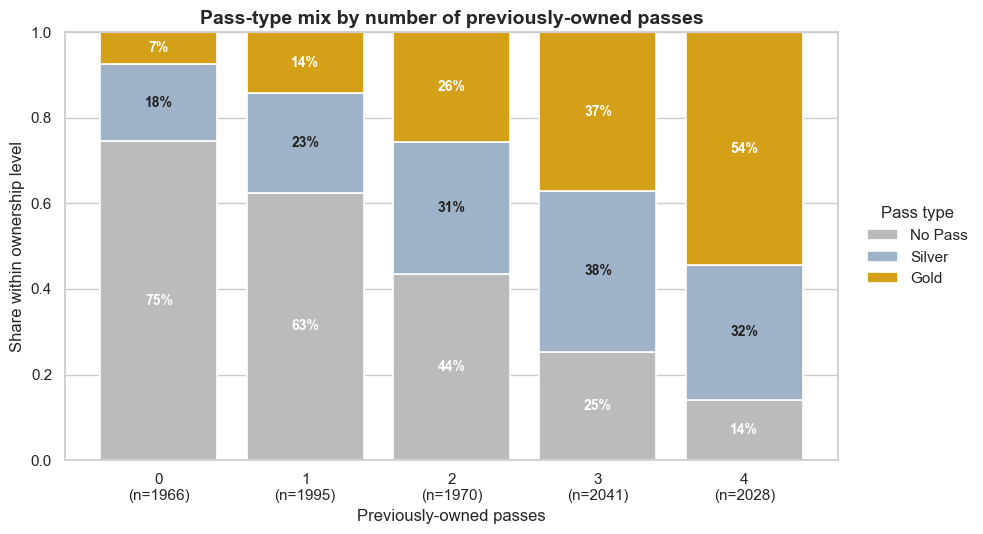

,Customers,No Pass %,Silver %,Gold %,Buy-rate %
Prev. owned,,,,,
0,1966,74.6,18.0,7.4,25.4
1,1995,62.5,23.3,14.2,37.5
2,1970,43.5,30.9,25.6,56.5
3,2041,25.3,37.5,37.1,74.7
4,2028,14.1,31.6,54.4,85.9


In [9]:
# Display labels/colours (re-defined so the cell runs standalone after prep)
order_raw  = ["None", "Silver", "Gold"]
order_disp = ["No Pass", "Silver", "Gold"]
bar_colors = ["#bbbbbb", "#9fb3c8", "#d4a017"]

# Counts and within-level shares of each pass type per ownership level
counts = (cust.groupby("Previously_Owned_Passes")["Pass_Type"]
              .value_counts().unstack()[order_raw].fillna(0))
shares = counts.div(counts.sum(axis=1), axis=0)          # row-normalised (share within level)
n_per_level = counts.sum(axis=1).astype(int)

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(shares))
x = np.arange(len(shares))
for cls_raw, cls_disp, col in zip(order_raw, order_disp, bar_colors):
    vals = shares[cls_raw].values
    ax.bar(x, vals, bottom=bottom, color=col, edgecolor="white",
           linewidth=1.2, label=cls_disp)
    # Label each segment with its share when it's big enough to read
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 0.05:
            ax.text(xi, b + v / 2, f"{v*100:.0f}%", ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if cls_disp != "Silver" else "#222")
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"{lvl}\n(n={n})" for lvl, n in zip(shares.index, n_per_level)])
ax.set_xlabel("Previously-owned passes")
ax.set_ylabel("Share within ownership level")
ax.set_ylim(0, 1)
ax.set_title("Pass-type mix by number of previously-owned passes",
             fontsize=14, fontweight="bold")
# Legend on the right, outside the plotting area.
ax.legend(title="Pass type", loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False, fontsize=11)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

# Buy-rate (any pass) per ownership level, as a backing table
backing = pd.DataFrame({
    "Customers":   n_per_level,
    "No Pass %":   (shares["None"]   * 100).round(1),
    "Silver %":    (shares["Silver"] * 100).round(1),
    "Gold %":      (shares["Gold"]   * 100).round(1),
    "Buy-rate %":  ((1 - shares["None"]) * 100).round(1),
})
backing.index.name = "Prev. owned"
display(backing)

## 2. Feature distributions

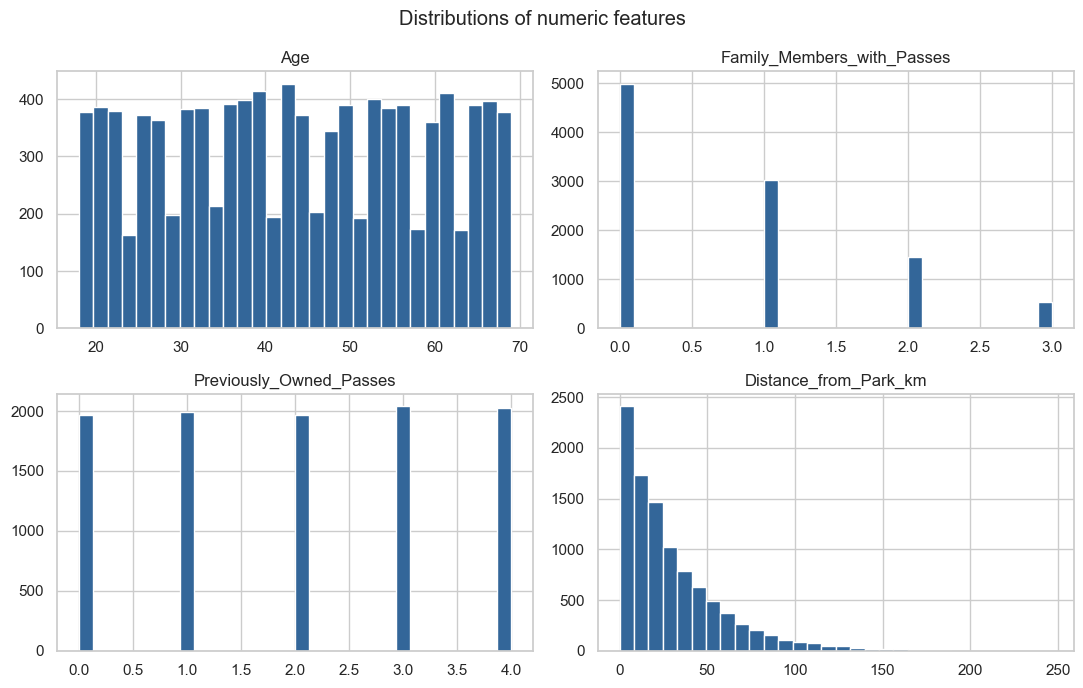

Club_Member share:
Club_Member
False    79.8 %
True     20.2 %
Name: proportion, dtype: str


In [10]:
num_cols = ["Age", "Family_Members_with_Passes", "Previously_Owned_Passes",
            "Distance_from_Park_km"]
cust[num_cols].hist(bins=30, figsize=(11, 7), color="#369")
plt.suptitle("Distributions of numeric features"); plt.tight_layout(); plt.show()

print("Club_Member share:")
print((cust.Club_Member.value_counts(normalize=True) * 100).round(1).astype(str) + " %")

## 3. What separates buyers from non-buyers?

We compare each feature across the three classes (`None`, `Silver`, `Gold`).

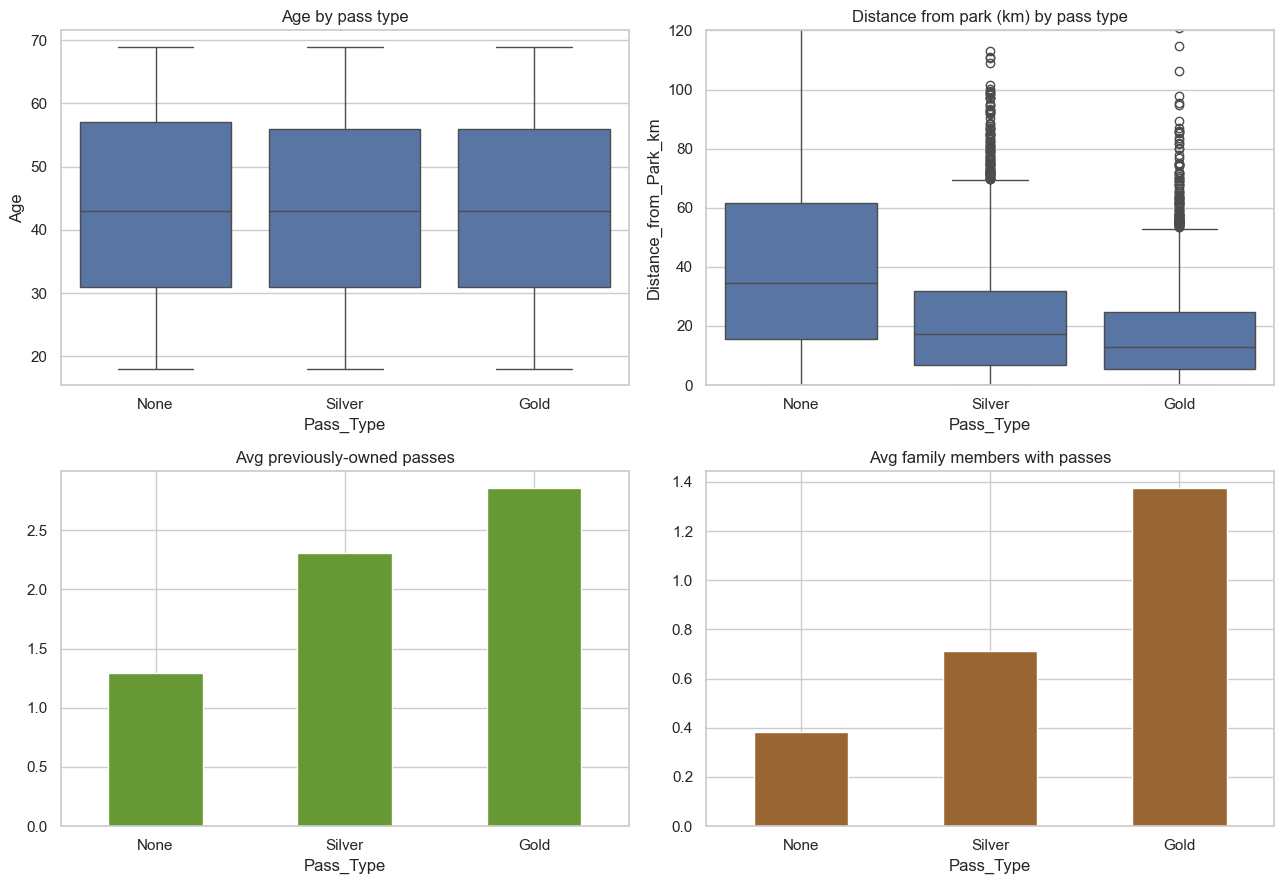

In [11]:
order = ["None", "Silver", "Gold"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(data=cust, x="Pass_Type", y="Age", order=order, ax=axes[0,0])
axes[0,0].set_title("Age by pass type")

sns.boxplot(data=cust, x="Pass_Type", y="Distance_from_Park_km", order=order, ax=axes[0,1])
axes[0,1].set_ylim(0, 120); axes[0,1].set_title("Distance from park (km) by pass type")

(cust.groupby("Pass_Type").Previously_Owned_Passes.mean().reindex(order)
     .plot.bar(ax=axes[1,0], color="#693"))
axes[1,0].set_title("Avg previously-owned passes"); axes[1,0].tick_params(axis="x", rotation=0)

(cust.groupby("Pass_Type").Family_Members_with_Passes.mean().reindex(order)
     .plot.bar(ax=axes[1,1], color="#963"))
axes[1,1].set_title("Avg family members with passes"); axes[1,1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

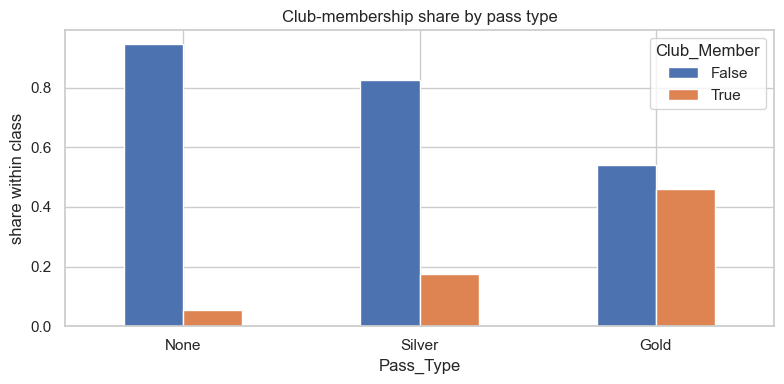

Club_Member,False,True
Pass_Type,,
None,0.946,0.054
Silver,0.825,0.175
Gold,0.540,0.460


In [12]:
# Club membership vs pass type
ct = pd.crosstab(cust.Pass_Type, cust.Club_Member, normalize="index").reindex(order)
ct.plot.bar(figsize=(8, 4))
plt.title("Club-membership share by pass type"); plt.xticks(rotation=0)
plt.ylabel("share within class"); plt.legend(title="Club_Member")
plt.tight_layout(); plt.show()
display(ct.round(3))

## 4. Feature correlations with buying a pass

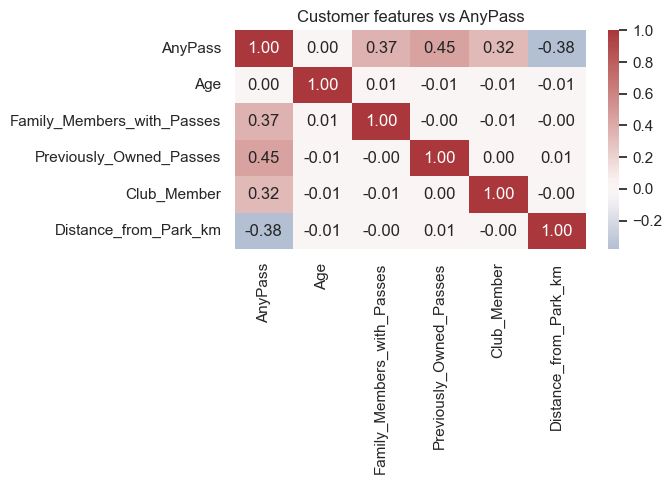

Correlation of each feature with AnyPass (sorted):
Previously_Owned_Passes       0.451
Family_Members_with_Passes    0.366
Club_Member                   0.324
Age                           0.000
Distance_from_Park_km        -0.383
Name: AnyPass, dtype: float64


In [13]:
numc = cust.assign(Club_Member=cust.Club_Member.astype(int))[
    ["AnyPass", "Age", "Family_Members_with_Passes", "Previously_Owned_Passes",
     "Club_Member", "Distance_from_Park_km"]]
plt.figure(figsize=(7, 5))
sns.heatmap(numc.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Customer features vs AnyPass"); plt.tight_layout(); plt.show()

print("Correlation of each feature with AnyPass (sorted):")
print(numc.corr()["AnyPass"].drop("AnyPass").sort_values(ascending=False).round(3))

## 5. Non-linear effects: purchase rate by feature bin

Pearson correlation only sees *linear* relationships - that is why `Age` scored ~0.00 above.
Here we bin each feature and plot the **share of customers who buy** within each bin, which
reveals non-monotonic shapes. We look at both targets: the binary buy-rate, and the full
`None`/`Silver`/`Gold` mix.

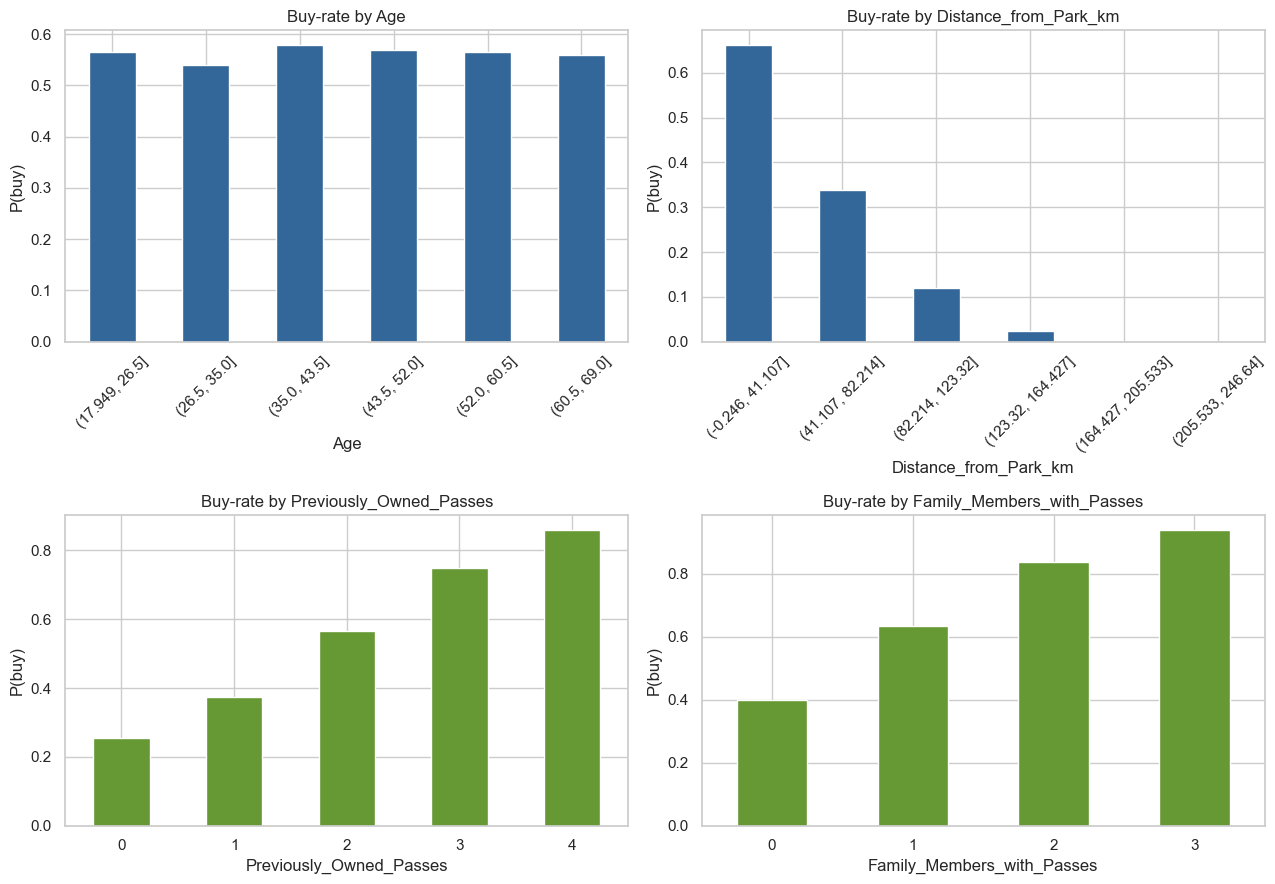

In [14]:
# Binary buy-rate within bins of each feature
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in [(axes[0,0], "Age"), (axes[0,1], "Distance_from_Park_km")]:
    b = pd.cut(cust[col], bins=6)
    cust.groupby(b, observed=True).AnyPass.mean().plot.bar(ax=ax, color="#369")
    ax.set_title(f"Buy-rate by {col}"); ax.set_ylabel("P(buy)")
    ax.tick_params(axis="x", rotation=45)

for ax, col in [(axes[1,0], "Previously_Owned_Passes"),
                (axes[1,1], "Family_Members_with_Passes")]:
    cust.groupby(col).AnyPass.mean().plot.bar(ax=ax, color="#693")
    ax.set_title(f"Buy-rate by {col}"); ax.set_ylabel("P(buy)")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

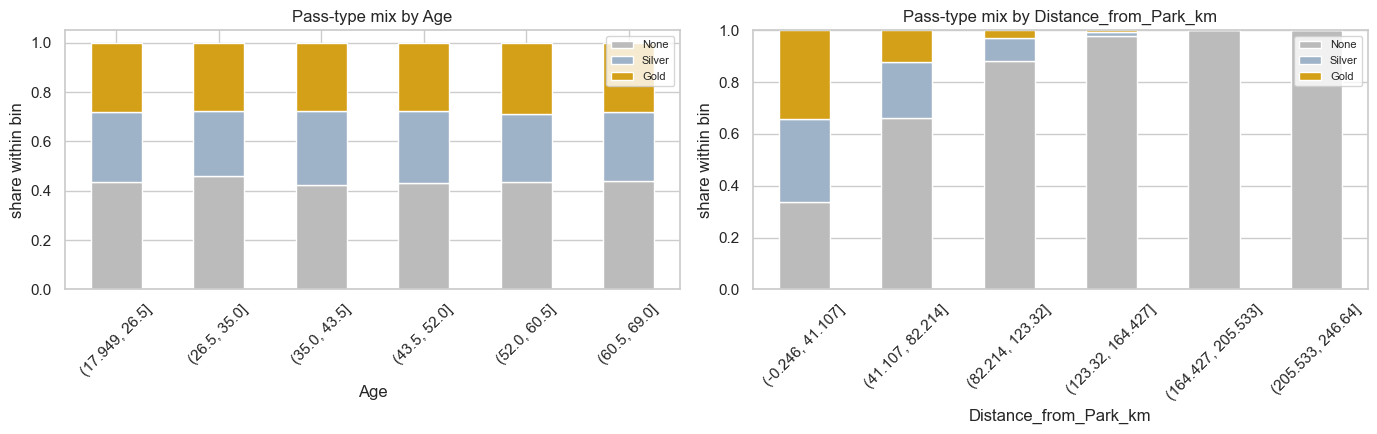

In [15]:
# 3-class mix (None/Silver/Gold) within bins of Age and Distance
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = ["#bbbbbb", "#9fb3c8", "#d4a017"]  # None, Silver, Gold
for ax, col in [(axes[0], "Age"), (axes[1], "Distance_from_Park_km")]:
    b = pd.cut(cust[col], bins=6)
    comp = (cust.groupby(b, observed=True).Pass_Type
                .value_counts(normalize=True).unstack()[order])
    comp.plot.bar(stacked=True, ax=ax, color=colors)
    ax.set_title(f"Pass-type mix by {col}"); ax.set_ylabel("share within bin")
    ax.tick_params(axis="x", rotation=45); ax.legend(title="", fontsize=8)
plt.tight_layout(); plt.show()

## 6. Feature interactions

The decision is likely driven by *combinations* of variables. Each heatmap shows the
**buy-rate** across two binned features at once - if the colour pattern is not just
horizontal/vertical bands, the two features interact.

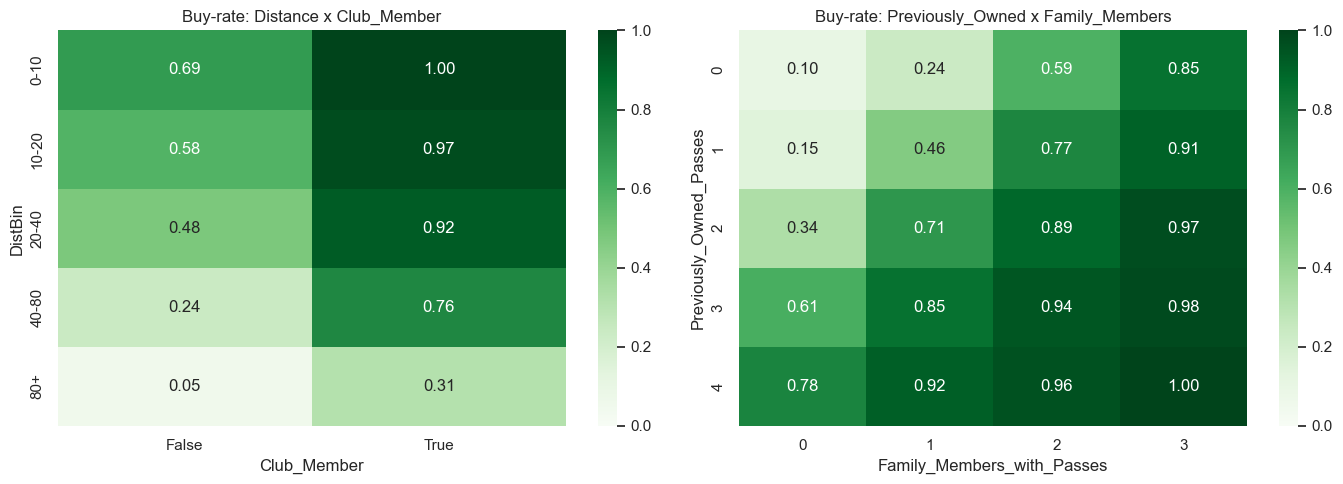

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance x Club_Member
dist_bin = pd.cut(cust.Distance_from_Park_km, bins=[0, 10, 20, 40, 80, 300],
                  labels=["0-10", "10-20", "20-40", "40-80", "80+"])
piv1 = (cust.assign(DistBin=dist_bin)
            .pivot_table(index="DistBin", columns="Club_Member",
                         values="AnyPass", aggfunc="mean", observed=True))
sns.heatmap(piv1, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Buy-rate: Distance x Club_Member")

# Previously_Owned x Family_Members
piv2 = cust.pivot_table(index="Previously_Owned_Passes",
                        columns="Family_Members_with_Passes",
                        values="AnyPass", aggfunc="mean")
sns.heatmap(piv2, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Buy-rate: Previously_Owned x Family_Members")
plt.tight_layout(); plt.show()

## 7. Gold vs Silver - a separate question

Sections 4-6 explained *whether* someone buys. But "what drives the decision" also covers
*which tier* they choose. Here we look **only at buyers** and ask what separates `Gold`
from `Silver`.

In [17]:
buyers = cust[cust.Pass_Type != "None"].copy()
buyers["IsGold"] = (buyers.Pass_Type == "Gold").astype(int)
print(f"Buyers: {len(buyers)} | Gold share among buyers: {buyers.IsGold.mean():.1%}")

feat = ["Age", "Family_Members_with_Passes", "Previously_Owned_Passes",
        "Distance_from_Park_km"]
print("\nMean feature value - Gold vs Silver:")
display(buyers.groupby("Pass_Type")[feat].mean().T.round(2))

bnum = buyers.assign(Club_Member=buyers.Club_Member.astype(int))[["IsGold"] + feat + ["Club_Member"]]
print("Correlation with IsGold (among buyers), sorted:")
print(bnum.corr()["IsGold"].drop("IsGold").sort_values(ascending=False).round(3))

Buyers: 5628 | Gold share among buyers: 49.7%

Mean feature value - Gold vs Silver:


Pass_Type,Gold,Silver
Age,43.61,43.47
Family_Members_with_Passes,1.37,0.71
Previously_Owned_Passes,2.85,2.31
Distance_from_Park_km,17.56,22.41


Correlation with IsGold (among buyers), sorted:
Family_Members_with_Passes    0.346
Club_Member                   0.307
Previously_Owned_Passes       0.212
Age                           0.005
Distance_from_Park_km        -0.132
Name: IsGold, dtype: float64


## 8. Model-based importance

Univariate views can miss interactions. A fitted model ranks features while accounting for
them. We report three complementary measures for **both** targets:

- **Mutual information** - model-free, captures non-linear dependence.
- **Random-forest permutation importance** - drop in test accuracy when a feature is shuffled
  (the textbook answer to *"which variables enable a good prediction"*).
- **Standardised logistic-regression coefficients** (binary target) - give the *direction* of each effect.

Accuracies are shown only to gauge how much signal exists (vs. the majority-class baseline);
this is exploration, not the final tuned model.

BINARY (AnyPass) | RF test acc: 0.906 | majority baseline: 0.563


,MutualInfo,RF_PermImportance,LogReg_coef_std
Previously_Owned_Passes,0.1205,0.1836,3.9459
Family_Members_with_Passes,0.0681,0.1489,3.6865
Distance_from_Park_km,0.0765,0.1411,-4.0934
Club_Member,0.0561,0.1078,3.3595
Age,0.0000,0.0038,0.0446


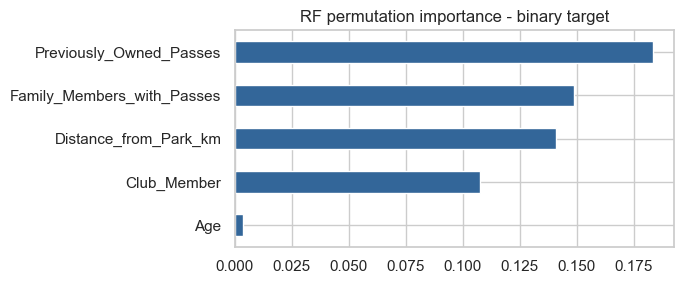

In [18]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ["Age", "Family_Members_with_Passes", "Previously_Owned_Passes",
            "Club_Member", "Distance_from_Park_km"]
X = cust[features].assign(Club_Member=cust.Club_Member.astype(int))

# ---- Binary target: AnyPass ----
y = cust.AnyPass
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1).fit(Xtr, ytr)
perm = permutation_importance(rf, Xte, yte, n_repeats=10, random_state=42, n_jobs=-1)
sc = StandardScaler().fit(Xtr)
lr = LogisticRegression(max_iter=1000).fit(sc.transform(Xtr), ytr)

report_bin = pd.DataFrame({
    "MutualInfo":        mutual_info_classif(X, y, random_state=42),
    "RF_PermImportance": perm.importances_mean,
    "LogReg_coef_std":   lr.coef_[0],
}, index=features).sort_values("RF_PermImportance", ascending=False)

print(f"BINARY (AnyPass) | RF test acc: {rf.score(Xte, yte):.3f} | "
      f"majority baseline: {max(y.mean(), 1 - y.mean()):.3f}")
display(report_bin.round(4))
report_bin["RF_PermImportance"].sort_values().plot.barh(color="#369", figsize=(7, 3))
plt.title("RF permutation importance - binary target"); plt.tight_layout(); plt.show()

In [19]:
# ---- 3-class target: None / Silver / Gold ----
y3 = cust.Pass_Type
Xtr, Xte, ytr, yte = train_test_split(X, y3, test_size=0.25, random_state=42, stratify=y3)

rf3 = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1).fit(Xtr, ytr)
perm3 = permutation_importance(rf3, Xte, yte, n_repeats=10, random_state=42, n_jobs=-1)

report_3c = pd.DataFrame({
    "MutualInfo":        mutual_info_classif(X, y3, random_state=42),
    "RF_PermImportance": perm3.importances_mean,
}, index=features).sort_values("RF_PermImportance", ascending=False)

print(f"3-CLASS (None/Silver/Gold) | RF test acc: {rf3.score(Xte, yte):.3f} | "
      f"majority baseline: {y3.value_counts(normalize=True).max():.3f}")
display(report_3c.round(4))

3-CLASS (None/Silver/Gold) | RF test acc: 0.832 | majority baseline: 0.437


,MutualInfo,RF_PermImportance
Previously_Owned_Passes,0.1385,0.2552
Family_Members_with_Passes,0.0989,0.2181
Distance_from_Park_km,0.0836,0.1859
Club_Member,0.0862,0.1662
Age,0.0000,-0.0007


## 9. Takeaways - what drives the season-pass decision

**Data prep:** `Pass_Type` NaN -> `"None"` (None 43.7% / Silver 28.3% / Gold 28.0%);
`Telephone_Number` dropped (ID); no remaining missing values or duplicate rows.

**The signal is strong and predictable.** A plain random forest already reaches:
- **Binary** (buy / not): **~0.91** test accuracy vs. 0.56 majority baseline.
- **3-class** (None/Silver/Gold): **~0.83** vs. 0.44 baseline.

**Variables that drive *whether* a customer buys** (consistent across correlation,
mutual information and RF permutation importance):

| Rank | Variable | Effect |
|------|----------|--------|
| 1 | `Previously_Owned_Passes` | **+** strongest driver - past owners renew |
| 2 | `Family_Members_with_Passes` | **+** households with passes buy more |
| 3 | `Distance_from_Park_km` | **-** the farther away, the less likely (logistic coef ~ -4) |
| 4 | `Club_Member` | **+** 46% of Gold buyers are club members vs 5% of non-buyers |
| 5 | `Age` | **~0 - carries essentially no information** (MI = 0.00 even non-linearly) |

**Interactions (Section 6):** club membership and short distance reinforce each other;
loyalty (`Previously_Owned`) combined with family passes pushes buy-rate highest.

**Gold vs Silver (Section 7):** among buyers (≈50% pick Gold), the tier is driven by
`Family_Members_with_Passes` (Gold 1.37 vs Silver 0.71), `Club_Member`, and
`Previously_Owned_Passes` - i.e. **loyal, family-oriented, nearby club members upgrade to Gold.**

**Key insight to flag for the board:** `Age` is *not* a useful predictor here -
the decision is about **loyalty, household, proximity and membership**, not life stage.

**Recommended next step:** build the predictive model on these features (drop or
de-prioritise `Age`); use Logistic Regression as an explainable baseline and a tuned
Random Forest / XGBoost for best accuracy, reporting permutation importance to the CEO/CTO.

> A clean modelling dataframe `cust` is ready (target recoded, ID dropped, `AnyPass` added).